# Specification Invariance: California Housing

**Do different models assign the same price tier to the same house?**

We train 4 common models (Ridge / Random Forest / GBDT / KNN) to classify
California houses into Low / Medium / High price tiers, then use mrv-lib to
measure how stable those tier labels are across models.

This is the core **specification invariance** question:
if you swap the model or the feature set, does your conclusion still hold?

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mrv

## 1. Load California Housing Data

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame
y = data.target  # median house value (in $100k)

print(f"Samples:     {len(df)}")
print(f"Features:    {list(df.columns[:8])}")
print(f"Price range: ${y.min()*100:.0f}k - ${y.max()*100:.0f}k")
df.head()

Samples:     20640
Features:    ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Price range: $15k - $500k


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Define Four Practical Models

Each model predicts house prices, then predictions are binned into
**Low (0) / Medium (1) / High (2)** tiers using training-set terciles.

| Model | Real-world analogue |
|-------|--------------------|
| **Ridge** | Bank credit scorecard (linear) |
| **Random Forest** | Zillow / Redfin ensemble model |
| **GBDT** | Kaggle-style gradient boosting |
| **KNN** | "Comparable sales" used by appraisers |

In [3]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.iloc[:, :8].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Tercile thresholds (from training set)
q33 = np.percentile(y_train, 33.3)
q66 = np.percentile(y_train, 66.6)

def to_tier(pred):
    """Continuous prediction -> Low(0) / Medium(1) / High(2) tier."""
    return np.where(pred < q33, 0, np.where(pred < q66, 1, 2))

models = {
    "Ridge (scorecard)": Ridge(alpha=1.0),
    "RF (Zillow)": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "GBDT (Kaggle)": GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    "KNN (comps)": KNeighborsRegressor(n_neighbors=10),
}

labels = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    tier = to_tier(pred)
    labels[name] = tier
    dist = pd.Series(tier).value_counts().sort_index()
    print(f"{name:<22s}  Low:{dist.get(0,0):>4d}  Mid:{dist.get(1,0):>4d}  High:{dist.get(2,0):>4d}")

print(f"\nTest set size: {len(X_test)}")

Ridge (scorecard)       Low:1347  Mid:2641  High:2204


RF (Zillow)             Low:1687  Mid:2491  High:2014


GBDT (Kaggle)           Low:1842  Mid:2257  High:2093


KNN (comps)             Low:1656  Mid:2502  High:2034

Test set size: 6192


## 3. mrv Validation: Do the Tiers Agree?

We pass the pre-computed tier labels straight into the recommended public API,
`mrv.rep_invariance_validator`, using a **passthrough model** (`lambda x: x`)
so the labels are used as-is. mrv doesn't care what model produced them -- it
only looks at the labels. The typed `RepInvarianceResult` carries the pairwise
ARI and the two-layer verdict.

In [4]:
# Passthrough model: the labels are already computed, so model_fn returns them unchanged.
result = mrv.rep_invariance_validator(
    model_fn=lambda x: x,
    admissible_class=labels,   # {model_name: integer tier labels}
    K=3,                       # Low / Medium / High tiers
)

asset = "asset"   # default asset key used by the functional API
passed = result.passes_partition[asset]
print(f"Mean ARI:  {result.mean_ari[asset]:.3f}   (threshold {result.ari_threshold}, {'PASS' if passed else 'FAIL'})")
print(f"Min  ARI:  {result.min_ari[asset]:.3f}")

Mean ARI:  0.479   (threshold 0.65, FAIL)
Min  ARI:  0.404


## 4. Which Model Pair Disagrees Most?

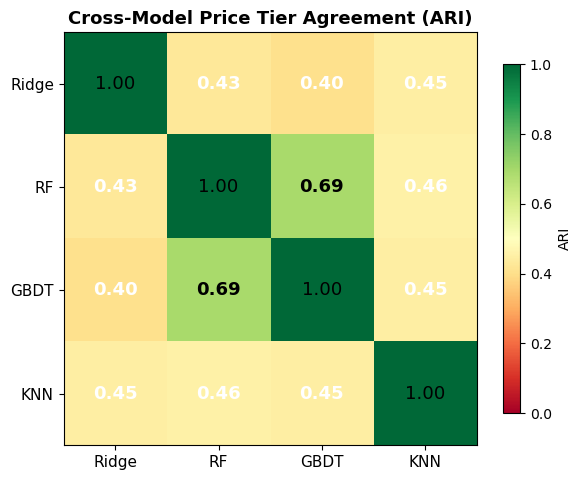

In [5]:
# Reconstruct the pairwise ARI matrix from result.ari_per_pair
model_names = list(labels.keys())
k = len(model_names)
ari_mat = pd.DataFrame(np.eye(k), index=model_names, columns=model_names)
for (a, b), v in result.ari_per_pair[asset].items():
    ari_mat.loc[a, b] = ari_mat.loc[b, a] = v

# Shorten labels for display
short = {"Ridge (scorecard)": "Ridge", "RF (Zillow)": "RF",
         "GBDT (Kaggle)": "GBDT", "KNN (comps)": "KNN"}
ari_display = ari_mat.rename(index=short, columns=short)

fig, ax = plt.subplots(figsize=(6, 5))
data = ari_display.values.astype(float)
names = list(ari_display.columns)
n = len(names)
im = ax.imshow(data, vmin=0, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names, fontsize=11)
ax.set_yticklabels(names, fontsize=11)
for i in range(n):
    for j in range(n):
        v = data[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=13,
                fontweight="bold" if i != j else "normal",
                color="white" if v < 0.5 else "black")
fig.colorbar(im, ax=ax, label="ARI", shrink=0.8)
ax.set_title("Cross-Model Price Tier Agreement (ARI)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. House-Level Disagreement

For the same house, different models may assign different tiers.

In [6]:
tier_names = {0: "Low", 1: "Mid", 2: "High"}
compare = pd.DataFrame(labels)
compare.columns = [short.get(c, c) for c in compare.columns]

# Full agreement rate
agree_all = (compare.nunique(axis=1) == 1).mean()
print(f"All 4 models agree:        {agree_all:.1%}")

# Houses where at least one model disagrees
disagree = compare[compare.nunique(axis=1) > 1]
print(f"At least one disagrees:    {len(disagree)} houses ({len(disagree)/len(compare):.1%})")

# Show first 10 disagreement cases
print(f"\nFirst 10 disagreement cases:")
sample = disagree.head(10).copy()
sample["Actual ($100k)"] = y_test.values[disagree.index[:10]].round(2)
for col in ["Ridge", "RF", "GBDT", "KNN"]:
    sample[col] = sample[col].map(tier_names)
print(sample.to_string())

All 4 models agree:        62.7%
At least one disagrees:    2308 houses (37.3%)

First 10 disagreement cases:
   Ridge    RF  GBDT   KNN  Actual ($100k)
1    Mid   Low   Low   Low            0.46
4   High   Mid   Mid  High            2.78
8   High  High  High   Mid            3.40
14  High  High   Mid  High            2.20
16  High   Mid   Mid  High            1.78
22   Mid   Mid   Low   Low            1.39
27   Mid   Low   Low   Low            0.95
28   Mid   Mid   Low   Mid            2.04
30   Mid   Low   Low   Low            0.85
34  High  High  High   Mid            2.72


## 6. Does Reducing Features Make It Worse?

We re-run with only 4 features (location + age) instead of all 8.

In [7]:
# Only 4 features: Latitude, Longitude, HouseAge, AveRooms
feat_cols = ["Latitude", "Longitude", "HouseAge", "AveRooms"]
X_all = df[feat_cols].values
X_geo_train, X_geo_test, _, _ = train_test_split(X_all, y, test_size=0.3, random_state=42)

scaler_geo = StandardScaler().fit(X_geo_train)
X_geo_train_s = scaler_geo.transform(X_geo_train)
X_geo_test_s = scaler_geo.transform(X_geo_test)

labels_geo = {}
for name, model_cls in [("Ridge", Ridge(alpha=1.0)),
                         ("RF", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)),
                         ("GBDT", GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)),
                         ("KNN", KNeighborsRegressor(n_neighbors=10))]:
    model_cls.fit(X_geo_train_s, y_train)
    labels_geo[name] = to_tier(model_cls.predict(X_geo_test_s))

result_geo = mrv.rep_invariance_validator(model_fn=lambda x: x, admissible_class=labels_geo, K=3)

mean_ari_full = result.mean_ari[asset]
mean_ari_geo = result_geo.mean_ari[asset]
print(f"All 8 features:   Mean ARI = {mean_ari_full:.3f}  {'PASS' if result.passes_partition[asset] else 'FAIL'}")
print(f"Only 4 features:  Mean ARI = {mean_ari_geo:.3f}  {'PASS' if result_geo.passes_partition[asset] else 'FAIL'}")
print(f"\nConclusion: fewer features {'increase' if mean_ari_geo < mean_ari_full else 'decrease'} cross-model disagreement")

All 8 features:   Mean ARI = 0.479  FAIL
Only 4 features:  Mean ARI = 0.395  FAIL

Conclusion: fewer features increase cross-model disagreement


## 7. What Does This Mean?

**The same houses get different price tiers depending on which model you use.**

In practice this means:

| Scenario | Risk |
|----------|------|
| Mortgage underwriting | Ridge says "low risk", RF says "medium risk" -- approval depends on model choice |
| Property tax assessment | Different models give different valuations -- unstable tax base |
| Zillow Zestimate | Swap the algorithm, your home value changes -- erodes user trust |

**mrv-lib quantifies this specification risk before deployment.**
ARI < 0.65 means your model's conclusions depend heavily on an arbitrary choice of algorithm.